# Univariate Inflation Forecasting - ARIMA Baseline Model
Inflation prediction using ARIMA with model improvement and future forecasts.

In [1]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load data
data_dir = os.path.join(os.path.abspath(''), 'data', 'raw')
df = pd.read_csv(os.path.join(data_dir, 'cpi_mom.csv'))
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Data shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Data shape: (360, 7)
Date range: 1995-01-01 to 2024-12-01


In [3]:
inflation = df['inflation'].dropna().values
cpi_index = df['cpi'].dropna().values


dates = df[df['inflation'].notna()]['date'].values

print(f"Inflation data points: {len(inflation)}")
print(f"Mean: {inflation.mean():.4f}, Std: {inflation.std():.4f}")
print(f"Min: {inflation.min():.4f}, Max: {inflation.max():.4f}\n")

print(f"CPI data points: {len(cpi_index)}")
print(f"Mean: {cpi_index.mean():.4f}, Std: {cpi_index.std():.4f}")
print(f"Min: {cpi_index.min():.4f}, Max: {cpi_index.max():.4f}\n")

def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print(f"ADF Statistic: {result[0]:.6f}")
    print(f"P-value: {result[1]:.6f}")
    print(f"Stationary: {'Yes' if result[1] < 0.05 else 'No'}")
    return result[1] < 0.05

print("Original series ADF test:")
is_stationary = adf_test(inflation)

if not is_stationary:
    inflation_diff = np.diff(inflation)
    print(f"Differenced series ADF test:")
    adf_test(inflation_diff)

print("\nKiểm định cho CPI index:")
adf_test(cpi_index)


Inflation data points: 360
Mean: 0.0204, Std: 0.7704
Min: -3.0948, Max: 2.4194

CPI data points: 360
Mean: 100.4688, Std: 0.7896
Min: 98.4600, Max: 103.9100

Original series ADF test:
ADF Statistic: -6.513445
P-value: 0.000000
Stationary: Yes

Kiểm định cho CPI index:
ADF Statistic: -3.777351
P-value: 0.003148
Stationary: Yes


True

In [4]:
print(df.head())

        date indicator    cpi  inflation  avg_year    unit processing_date
0 1995-01-01   cpi_mom  103.8  -0.385356   101.025  points      2026-04-18
1 1995-02-01   cpi_mom  103.4  -0.385356   101.025  points      2026-04-18
2 1995-03-01   cpi_mom  100.2  -3.094778   101.025  points      2026-04-18
3 1995-04-01   cpi_mom  101.0   0.798403   101.025  points      2026-04-18
4 1995-05-01   cpi_mom  101.8   0.792079   101.025  points      2026-04-18


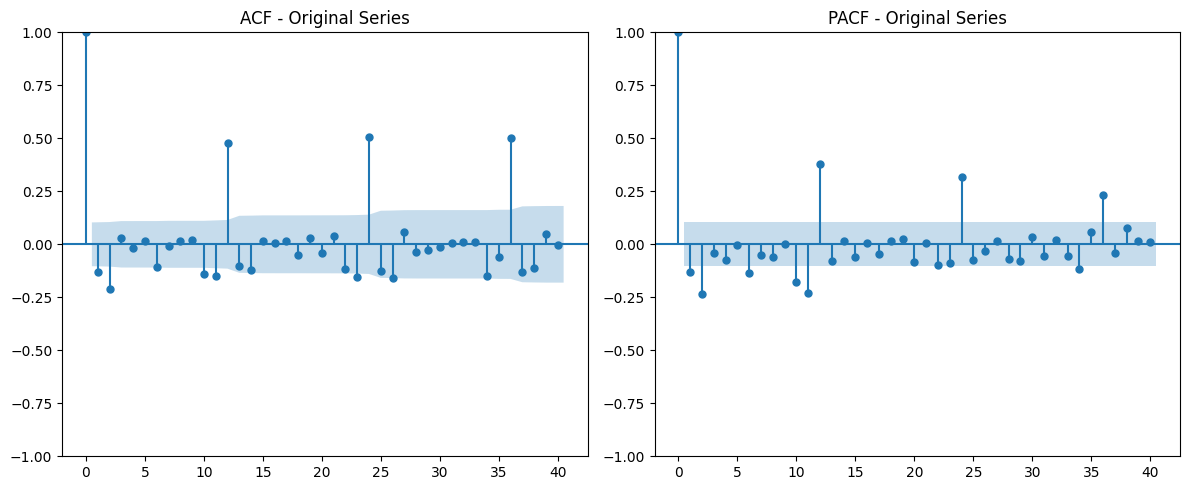

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_acf(inflation, lags=40, ax=axes[0], title='ACF - Original Series')
plot_pacf(inflation, lags=40, ax=axes[1], title='PACF - Original Series')

plt.tight_layout()
plt.show()


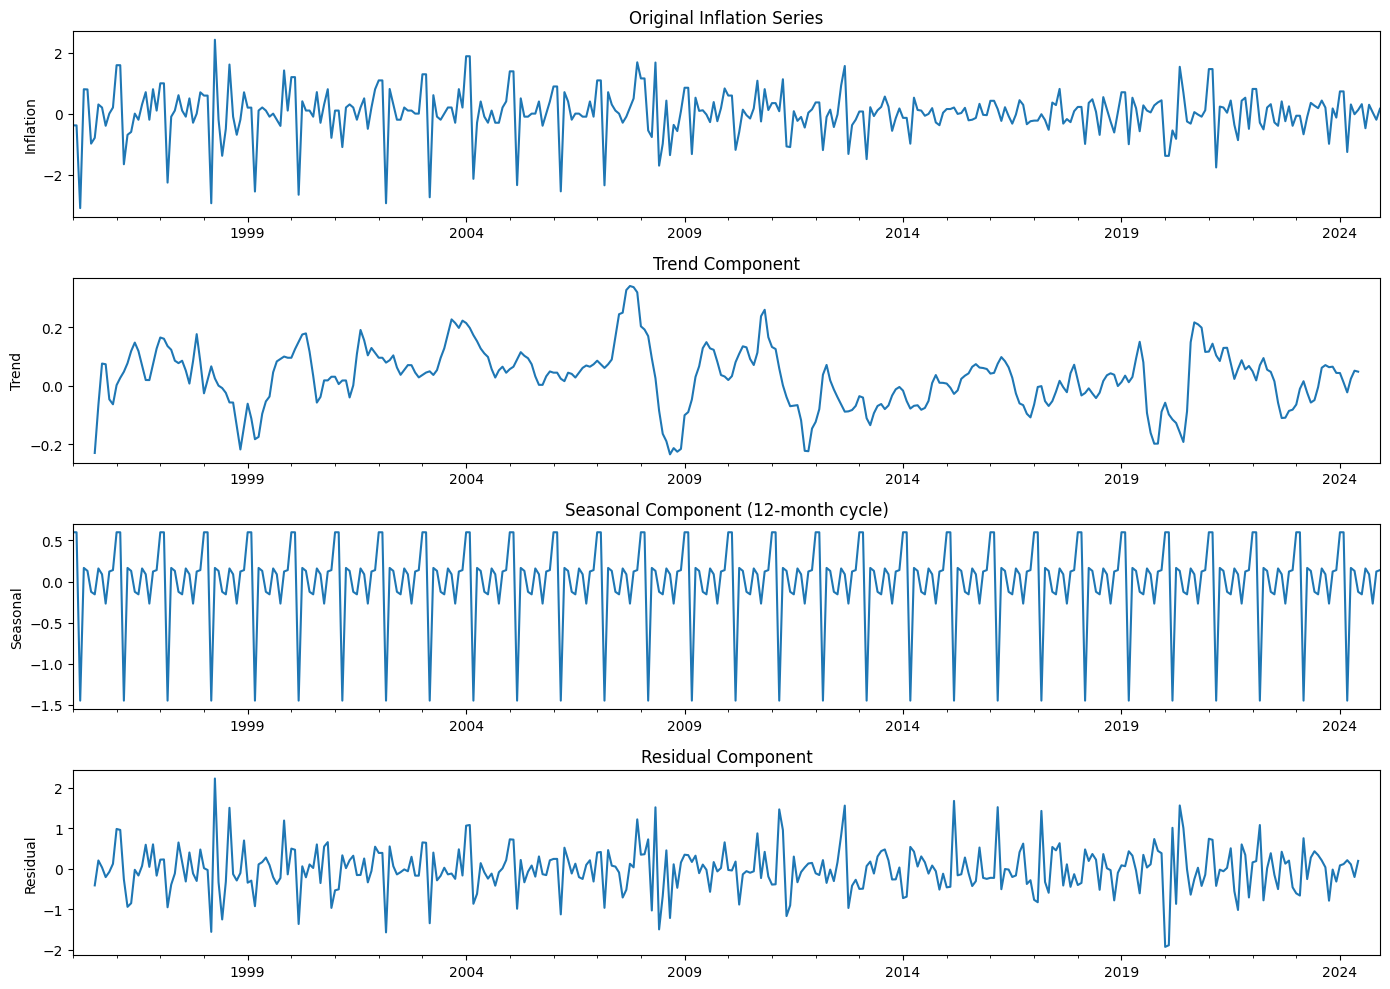

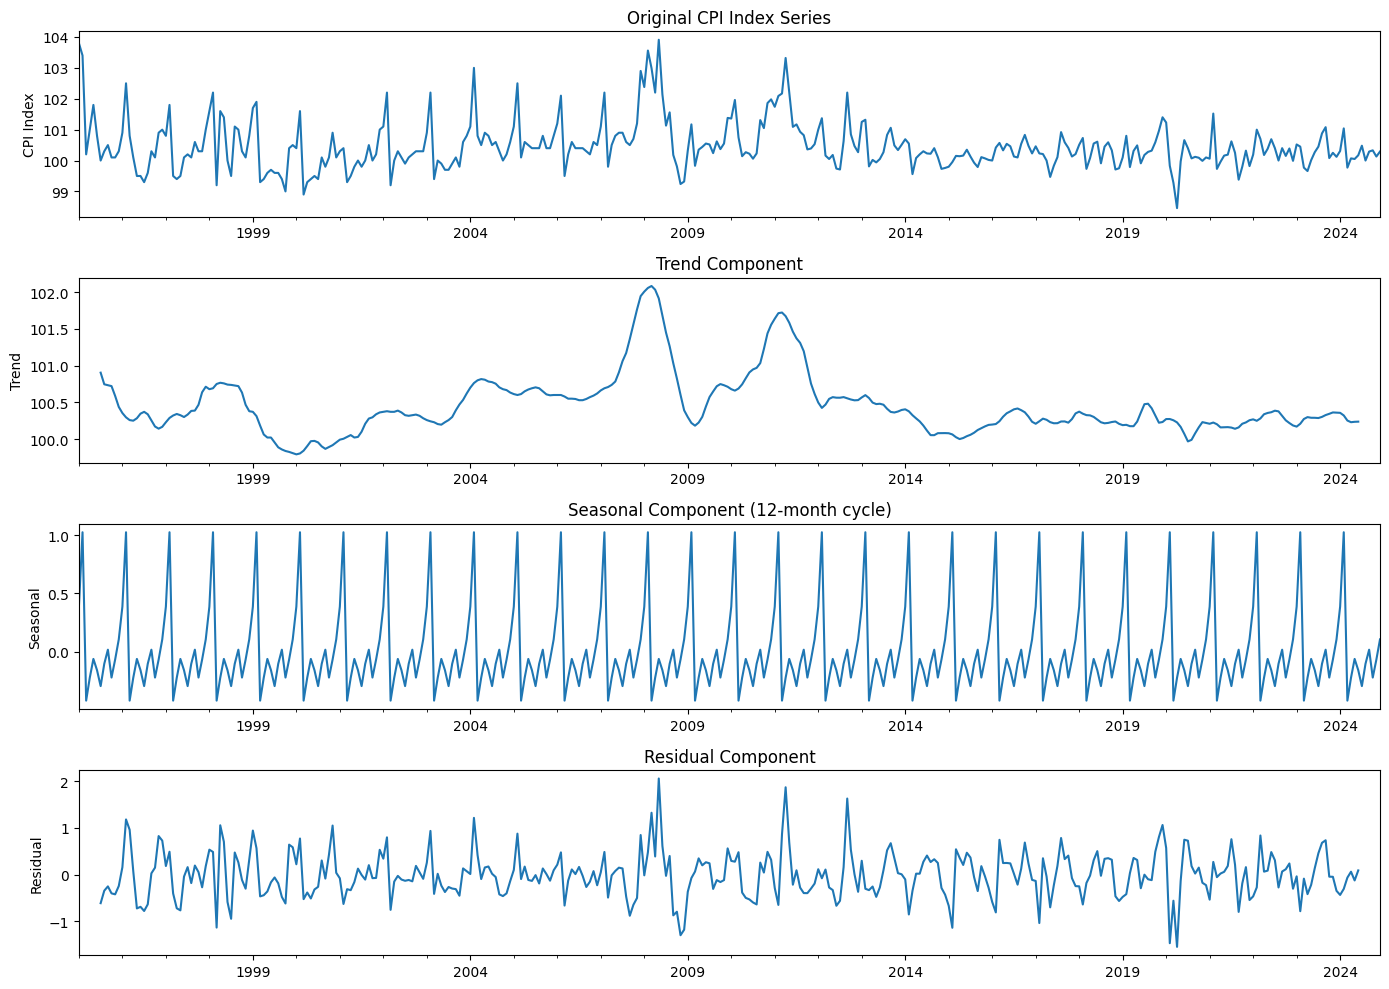

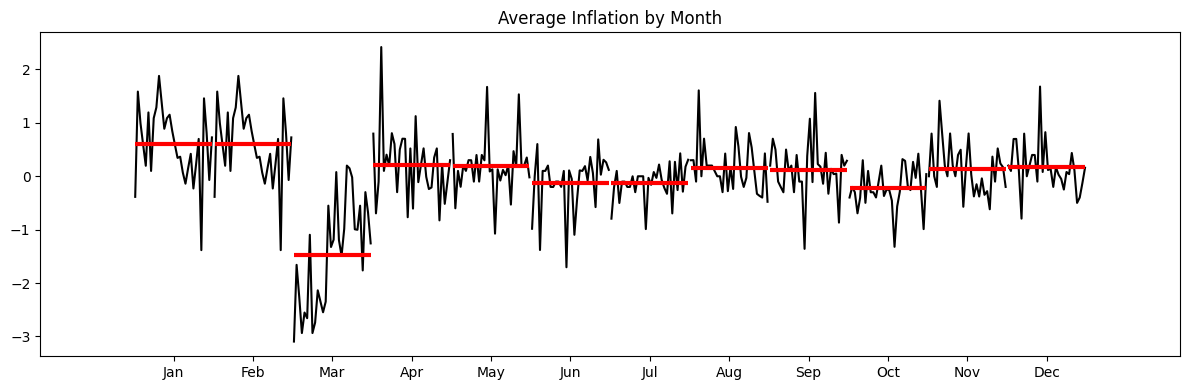

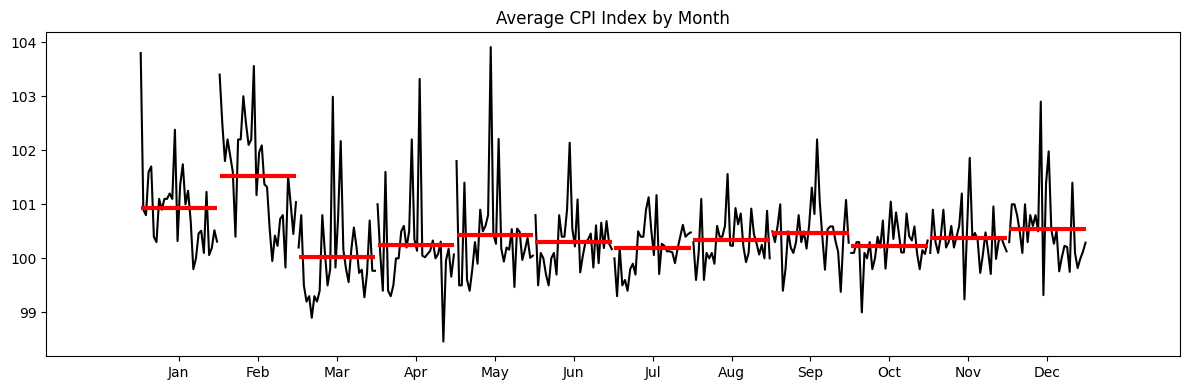


Seasonal Analysis:
Trend strength: 0.0278
Seasonal strength: 0.4454

Monthly average inflation:
  Month  1: 0.5976
  Month  2: 0.5976
  Month  3: -1.4721
  Month  4: 0.2179
  Month  5: 0.1832
  Month  6: -0.1221
  Month  7: -0.1198
  Month  8: 0.1615
  Month  9: 0.1227
  Month 10: -0.2285
  Month 11: 0.1387
  Month 12: 0.1681


In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import month_plot

ts_indexed = pd.Series(inflation, index=pd.to_datetime(dates))
ts_cpi_index = pd.Series(cpi_index, index=pd.to_datetime(dates))
# dùng STL 
decomposition = seasonal_decompose(ts_indexed, model='stl', period=12)
decomposition_cpi = seasonal_decompose(ts_cpi_index, model='stl', period=12)

# inflation
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Original Inflation Series')
axes[0].set_ylabel('Inflation')
decomposition.trend.plot(ax=axes[1], title='Trend Component')
axes[1].set_ylabel('Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component (12-month cycle)')
axes[2].set_ylabel('Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual Component')
axes[3].set_ylabel('Residual')
plt.tight_layout()
plt.show()
# CPI index
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition_cpi.observed.plot(ax=axes[0], title='Original CPI Index Series')
axes[0].set_ylabel('CPI Index')
decomposition_cpi.trend.plot(ax=axes[1], title='Trend Component')
axes[1].set_ylabel('Trend')
decomposition_cpi.seasonal.plot(ax=axes[2], title='Seasonal Component (12-month cycle)')
axes[2].set_ylabel('Seasonal')
decomposition_cpi.resid.plot(ax=axes[3], title='Residual Component')
axes[3].set_ylabel('Residual')
plt.tight_layout()
plt.show()                           

fig, ax = plt.subplots(figsize=(12, 4))
month_plot(ts_indexed, ax=ax)
ax.set_title('Average Inflation by Month')
plt.tight_layout()
plt.show()

# cpi inflation
fig, ax = plt.subplots(figsize=(12, 4))
month_plot(ts_cpi_index, ax=ax)
ax.set_title('Average CPI Index by Month')
plt.tight_layout()
plt.show()

# Seasonal statistics
print("\nSeasonal Analysis:")
print(f"Trend strength: {1 - (decomposition.resid.var() / (decomposition.trend + decomposition.resid).var()):.4f}")
print(f"Seasonal strength: {1 - (decomposition.resid.var() / (decomposition.seasonal + decomposition.resid).var()):.4f}")
print(f"\nMonthly average inflation:")
monthly_avg = ts_indexed.groupby(ts_indexed.index.month).mean()
for month in range(1, 13):
    print(f"  Month {month:2d}: {monthly_avg[month]:.4f}")

In [7]:
trend = decomposition.trend.dropna()
peaks = trend[trend == trend.rolling(window=12, center=True).max()]
troughs = trend[trend == trend.rolling(window=12, center=True).min()]

for date, value in peaks.items():
    print(f"  {date.strftime('%Y-%m')}: {value:.4f}")

trend_volatility = trend.std()
print(f"\nTrend volatility (std): {trend_volatility:.4f}")
print(f"Trend range: [{trend.min():.4f}, {trend.max():.4f}]")

  1996-06: 0.1477
  1997-01: 0.1651
  1997-11: 0.1766
  2000-05: 0.1791
  2001-08: 0.1909
  2003-09: 0.2271
  2005-04: 0.1149
  2007-10: 0.3415
  2009-07: 0.1491
  2010-11: 0.2600
  2012-04: 0.0711
  2013-01: -0.0359
  2013-12: -0.0044
  2014-10: 0.0365
  2015-09: 0.0738
  2016-04: 0.0980
  2017-12: 0.0718
  2018-10: 0.0425
  2019-06: 0.1504
  2020-09: 0.2168
  2022-04: 0.0946
  2023-09: 0.0705

Trend volatility (std): 0.1013
Trend range: [-0.2352, 0.3415]


In [8]:
train_size = int(len(inflation) * 0.8)
train_data = inflation[:train_size]
test_data = inflation[train_size:]

print(f"Train set: {len(train_data)} samples")
print(f"Test set: {len(test_data)} samples")
print(f"Train range: {dates[0]} to {dates[train_size-1]}")
print(f"Test range: {dates[train_size]} to {dates[-1]}")

Train set: 288 samples
Test set: 72 samples
Train range: 1995-01-01T00:00:00.000000000 to 2018-12-01T00:00:00.000000000
Test range: 2019-01-01T00:00:00.000000000 to 2024-12-01T00:00:00.000000000


In [9]:

naive_pred = np.full(len(test_data), train_data[-1])
mae_naive = mean_absolute_error(test_data, naive_pred)
rmse_naive = np.sqrt(mean_squared_error(test_data, naive_pred))
mape_naive = np.mean(np.abs((test_data - naive_pred) / test_data)) * 100

print(f"  Last training value: {train_data[-1]:.4f}")
print(f"  MAE: {mae_naive:.4f}, RMSE: {rmse_naive:.4f}, MAPE: {mape_naive:.2f}%")

# Seasonal Naive: use value from 12 months ago
seasonal_naive_pred = np.zeros(len(test_data))
test_start_idx = train_size
for i in range(len(test_data)):
    seasonal_idx = test_start_idx + i - 12
    if seasonal_idx >= 0:
        seasonal_naive_pred[i] = inflation[seasonal_idx]
    else:
        seasonal_naive_pred[i] = inflation[0]

mae_seasonal = mean_absolute_error(test_data, seasonal_naive_pred)
rmse_seasonal = np.sqrt(mean_squared_error(test_data, seasonal_naive_pred))
mape_seasonal = np.mean(np.abs((test_data - seasonal_naive_pred) / test_data)) * 100

print(f"  MAE: {mae_seasonal:.4f}, RMSE: {rmse_seasonal:.4f}, MAPE: {mape_seasonal:.2f}%")

print("\nNaive vs Seasonal Naive:")
naive_comparison = pd.DataFrame({
    'Model': ['Naive', 'Seasonal Naive (lag=12)'],
    'MAE': [mae_naive, mae_seasonal],
    'RMSE': [rmse_naive, rmse_seasonal],
    'MAPE (%)': [mape_naive, mape_seasonal]
})
print(naive_comparison.to_string(index=False))

  Last training value: 0.0401
  MAE: 0.4634, RMSE: 0.6214, MAPE: 98.33%
  MAE: 0.6596, RMSE: 0.8785, MAPE: 288.09%

Naive vs Seasonal Naive:
                  Model      MAE     RMSE   MAPE (%)
                  Naive 0.463433 0.621402  98.331316
Seasonal Naive (lag=12) 0.659606 0.878469 288.090429


In [10]:
print("\nAR(1) Model:")
ar_model = ARIMA(train_data, order=(1, 0, 0))
ar_fit = ar_model.fit()
ar_pred = ar_fit.get_forecast(steps=len(test_data)).predicted_mean

mae_ar = mean_absolute_error(test_data, ar_pred)
rmse_ar = np.sqrt(mean_squared_error(test_data, ar_pred))
mape_ar = np.mean(np.abs((test_data - ar_pred) / test_data)) * 100

print(f"AR(1) - MAE: {mae_ar:.4f}, RMSE: {rmse_ar:.4f}, MAPE: {mape_ar:.2f}%")

# MA(1) - only uses past errors
print("\nMA(1) Model:")
ma_model = ARIMA(train_data, order=(0, 0, 1))
ma_fit = ma_model.fit()
ma_pred = ma_fit.get_forecast(steps=len(test_data)).predicted_mean

mae_ma = mean_absolute_error(test_data, ma_pred)
rmse_ma = np.sqrt(mean_squared_error(test_data, ma_pred))
mape_ma = np.mean(np.abs((test_data - ma_pred) / test_data)) * 100

print(f"MA(1) - MAE: {mae_ma:.4f}, RMSE: {rmse_ma:.4f}, MAPE: {mape_ma:.2f}%")

# Simple comparison
print("\nAR vs MA Comparison:")
comparison_simple = pd.DataFrame({
    'Model': ['AR(1)', 'MA(1)'],
    'MAE': [mae_ar, mae_ma],
    'RMSE': [rmse_ar, rmse_ma],
    'MAPE (%)': [mape_ar, mape_ma]
})
print(comparison_simple.to_string(index=False))


AR(1) Model:
AR(1) - MAE: 0.4665, RMSE: 0.6212, MAPE: 98.69%

MA(1) Model:
MA(1) - MAE: 0.4658, RMSE: 0.6206, MAPE: 98.57%

AR vs MA Comparison:
Model      MAE     RMSE  MAPE (%)
AR(1) 0.466541 0.621214 98.693316
MA(1) 0.465850 0.620579 98.570096


In [11]:

# ARIMA(p,d,q)
# AR(p) MA(q) 

print("Baseline ARIMA(2,0,2) - from ACF/PACF analysis:")
baseline_model = ARIMA(train_data, order=(1, 0,1))
baseline_fit = baseline_model.fit()
print(baseline_fit.summary().tables[1])

baseline_pred = baseline_fit.get_forecast(steps=len(test_data)).predicted_mean

mae_base = mean_absolute_error(test_data, baseline_pred)
rmse_base = np.sqrt(mean_squared_error(test_data, baseline_pred))
mape_base = np.mean(np.abs((test_data - baseline_pred) / test_data)) * 100

print(f"Baseline Results - MAE: {mae_base:.4f}, RMSE: {rmse_base:.4f}, MAPE: {mape_base:.2f}%")

Baseline ARIMA(2,0,2) - from ACF/PACF analysis:


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0274      0.021      1.307      0.191      -0.014       0.068
ar.L1          0.6126      0.074      8.239      0.000       0.467       0.758
ma.L1         -0.8612      0.055    -15.534      0.000      -0.970      -0.753
sigma2         0.5893      0.034     17.485      0.000       0.523       0.655
Baseline Results - MAE: 0.4612, RMSE: 0.6186, MAPE: 97.18%


In [12]:
print("Finding optimal ARIMA parameters (d fixed at 0)...")
best_model = auto_arima(train_data, start_p=0, max_p=5, d=0, start_q=0, max_q=5, 
                        seasonal=False, stepwise=True, trace=False, n_fits=50)

print(f"Best ARIMA order: {best_model.order}")
print(best_model.summary())

improved_pred = best_model.predict(n_periods=len(test_data))

mae_imp = mean_absolute_error(test_data, improved_pred)
rmse_imp = np.sqrt(mean_squared_error(test_data, improved_pred))
mape_imp = np.mean(np.abs((test_data - improved_pred) / test_data)) * 100

print(f"Improved Results - MAE: {mae_imp:.4f}, RMSE: {rmse_imp:.4f}, MAPE: {mape_imp:.2f}%")

Finding optimal ARIMA parameters (d fixed at 0)...


Best ARIMA order: (0, 0, 2)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  288
Model:               SARIMAX(0, 0, 2)   Log Likelihood                -333.504
Date:                Wed, 20 May 2026   AIC                            673.007
Time:                        13:55:40   BIC                            683.996
Sample:                             0   HQIC                           677.411
                                - 288                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2028      0.044     -4.583      0.000      -0.290      -0.116
ma.L2         -0.2446      0.061     -4.008      0.000      -0.364      -0.125
sigma2         0.5930   

SARIMA

## SARIMA Models (Seasonal ARIMA)

Original series length: 360
After seasonal differencing length: 348
Mean: 0.0128, Std: 0.7695

ADF test - After seasonal differencing:
ADF Statistic: -10.000624
P-value: 0.000000
Stationary: Yes


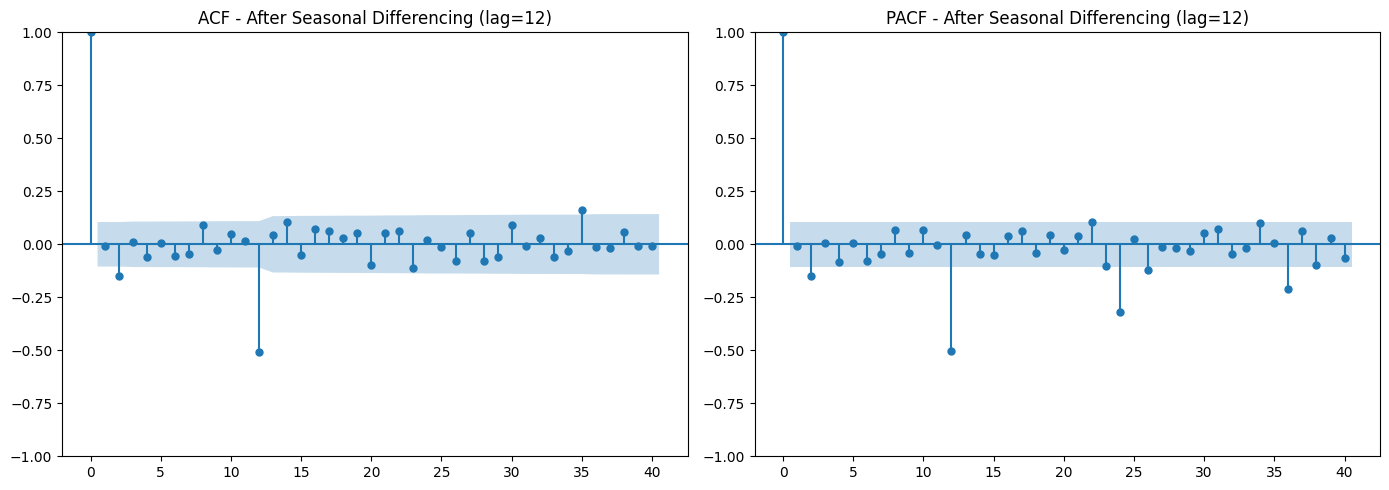

In [13]:
# ACF và PACF sau khi sai phân mùa vụ (Seasonal Differencing)
# Seasonal differencing: Y_diff = Y_t - Y_{t-12}

inflation_seasonal_diff = inflation[12:] - inflation[:-12]

print(f"Original series length: {len(inflation)}")
print(f"After seasonal differencing length: {len(inflation_seasonal_diff)}")
print(f"Mean: {inflation_seasonal_diff.mean():.4f}, Std: {inflation_seasonal_diff.std():.4f}")

print("\nADF test - After seasonal differencing:")
adf_result = adfuller(inflation_seasonal_diff, autolag='AIC')
print(f"ADF Statistic: {adf_result[0]:.6f}")
print(f"P-value: {adf_result[1]:.6f}")
print(f"Stationary: {'Yes' if adf_result[1] < 0.05 else 'No'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(inflation_seasonal_diff, lags=40, ax=axes[0], title='ACF - After Seasonal Differencing (lag=12)')
plot_pacf(inflation_seasonal_diff, lags=40, ax=axes[1], title='PACF - After Seasonal Differencing (lag=12)')

plt.tight_layout()
plt.show()

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Baseline SARIMA(1,0,1)(1,1,1,12)
print("\nBaseline SARIMA(1,0,1)(1,1,1,12):")
sarima_baseline = SARIMAX(train_data, order=(1, 0, 1), seasonal_order=(1, 1, 1, 12))
sarima_baseline_fit = sarima_baseline.fit(disp=False)
print(sarima_baseline_fit.summary().tables[1])

sarima_baseline_pred = sarima_baseline_fit.get_forecast(steps=len(test_data)).predicted_mean

mae_sarima_base = mean_absolute_error(test_data, sarima_baseline_pred)
rmse_sarima_base = np.sqrt(mean_squared_error(test_data, sarima_baseline_pred))
mape_sarima_base = np.mean(np.abs((test_data - sarima_baseline_pred) / test_data)) * 100

print(f"Baseline SARIMA Results - MAE: {mae_sarima_base:.4f}, RMSE: {rmse_sarima_base:.4f}, MAPE: {mape_sarima_base:.2f}%")


Baseline SARIMA(1,0,1)(1,1,1,12):
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8269      0.081     10.217      0.000       0.668       0.986
ma.L1         -0.9213      0.066    -14.002      0.000      -1.050      -0.792
ar.S.L12      -0.1243      0.087     -1.431      0.153      -0.295       0.046
ma.S.L12      -0.6943      0.062    -11.180      0.000      -0.816      -0.573
sigma2         0.3163      0.020     15.975      0.000       0.277       0.355
Baseline SARIMA Results - MAE: 0.4602, RMSE: 0.5971, MAPE: 127.19%


In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Baseline SARIMA(1,0,1)(1,1,1,12)
print("\nBaseline SARIMA(1,0,1)(0,1,1,12):")
sarima_baseline = SARIMAX(train_data, order=(1, 0, 1), seasonal_order=(0, 1, 1, 12))
sarima_baseline_fit = sarima_baseline.fit(disp=False)
print(sarima_baseline_fit.summary().tables[1])

sarima_baseline_pred = sarima_baseline_fit.get_forecast(steps=len(test_data)).predicted_mean

mae_sarima_base = mean_absolute_error(test_data, sarima_baseline_pred)
rmse_sarima_base = np.sqrt(mean_squared_error(test_data, sarima_baseline_pred))
mape_sarima_base = np.mean(np.abs((test_data - sarima_baseline_pred) / test_data)) * 100

print(f"Baseline SARIMA Results - MAE: {mae_sarima_base:.4f}, RMSE: {rmse_sarima_base:.4f}, MAPE: {mape_sarima_base:.2f}%")


Baseline SARIMA(1,0,1)(0,1,1,12):
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8308      0.076     10.919      0.000       0.682       0.980
ma.L1         -0.9252      0.061    -15.061      0.000      -1.046      -0.805
ma.S.L12      -0.7486      0.044    -16.862      0.000      -0.836      -0.662
sigma2         0.3192      0.020     15.933      0.000       0.280       0.358
Baseline SARIMA Results - MAE: 0.4503, RMSE: 0.5876, MAPE: 129.04%


In [16]:
print("\nFinding optimal SARIMA parameters (12-month seasonality)...")
sarima_best = auto_arima(train_data, start_p=0, max_p=3, d=0, start_q=0, max_q=3,
                         seasonal=True, m=12, start_P=0, max_P=2, start_Q=0, max_Q=2,
                         stepwise=True, trace=False, n_fits=50)

print(f"Best SARIMA order: {sarima_best.order}")
print(f"Seasonal order: {sarima_best.seasonal_order}")
print(sarima_best.summary())

sarima_improved_pred = sarima_best.predict(n_periods=len(test_data))

mae_sarima_imp = mean_absolute_error(test_data, sarima_improved_pred)
rmse_sarima_imp = np.sqrt(mean_squared_error(test_data, sarima_improved_pred))
mape_sarima_imp = np.mean(np.abs((test_data - sarima_improved_pred) / test_data)) * 100

print(f"Improved SARIMA Results - MAE: {mae_sarima_imp:.4f}, RMSE: {rmse_sarima_imp:.4f}, MAPE: {mape_sarima_imp:.2f}%")


Finding optimal SARIMA parameters (12-month seasonality)...
Best SARIMA order: (1, 0, 1)
Seasonal order: (1, 0, 2, 12)
                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                  288
Model:             SARIMAX(1, 0, 1)x(1, 0, [1, 2], 12)   Log Likelihood                -245.823
Date:                                 Wed, 20 May 2026   AIC                            503.646
Time:                                         13:56:16   BIC                            525.624
Sample:                                              0   HQIC                           512.454
                                                 - 288                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------

# Deep Learning Models: MLP, LSTM, GRU, TCN

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

scaler = MinMaxScaler(feature_range=(0, 1))
inflation_scaled = scaler.fit_transform(inflation.reshape(-1, 1)).flatten()

train_scaled = inflation_scaled[:train_size]
test_scaled = inflation_scaled[train_size:]

def create_lag_features(data, lag=3):
    X, y = [], []
    for i in range(len(data) - lag):
        X.append(data[i:i+lag])
        y.append(data[i+lag])
    return np.array(X), np.array(y)

lag = 3
X_train, y_train = create_lag_features(train_scaled, lag)
X_test, y_test = create_lag_features(test_scaled, lag)

print(f"\nLag features (lag={lag}):")
print(f"  X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"  X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


Lag features (lag=3):
  X_train shape: (285, 3), y_train shape: (285,)
  X_test shape: (69, 3), y_test shape: (69,)


In [22]:
# 1. MLP Model
mlp_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(lag,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])
mlp_model.compile(optimizer='adam', loss='mse')
mlp_model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

mlp_pred_scaled = mlp_model.predict(X_test, verbose=0).flatten()
mlp_pred = scaler.inverse_transform(mlp_pred_scaled.reshape(-1, 1)).flatten()

y_test_actual = test_data[lag:]
mae_mlp = mean_absolute_error(y_test_actual, mlp_pred)
rmse_mlp = np.sqrt(mean_squared_error(y_test_actual, mlp_pred))
mape_mlp = np.mean(np.abs((y_test_actual - mlp_pred) / y_test_actual)) * 100

print(f"MLP - MAE: {mae_mlp:.4f}, RMSE: {rmse_mlp:.4f}, MAPE: {mape_mlp:.2f}%")

MLP - MAE: 0.4467, RMSE: 0.5724, MAPE: 140.30%


In [23]:
# 2. LSTM Model
lstm_model = keras.Sequential([
    layers.LSTM(64, activation='relu', input_shape=(lag, 1), return_sequences=True),
    layers.LSTM(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
X_train_3d = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_3d = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
lstm_model.fit(X_train_3d, y_train, epochs=50, batch_size=16, verbose=0)

lstm_pred_scaled = lstm_model.predict(X_test_3d, verbose=0).flatten()
lstm_pred = scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()

mae_lstm = mean_absolute_error(y_test_actual, lstm_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
mape_lstm = np.mean(np.abs((y_test_actual - lstm_pred) / y_test_actual)) * 100

print(f"LSTM - MAE: {mae_lstm:.4f}, RMSE: {rmse_lstm:.4f}, MAPE: {mape_lstm:.2f}%")


LSTM - MAE: 0.4461, RMSE: 0.6052, MAPE: 124.59%


In [ ]:
# 3. GRU Model
gru_model = keras.Sequential([
    layers.GRU(64, activation='relu', input_shape=(lag, 1), return_sequences=True),
    layers.GRU(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train_3d, y_train, epochs=50, batch_size=16, verbose=0)

gru_pred_scaled = gru_model.predict(X_test_3d, verbose=0).flatten()
gru_pred = scaler.inverse_transform(gru_pred_scaled.reshape(-1, 1)).flatten()

mae_gru = mean_absolute_error(y_test_actual, gru_pred)
rmse_gru = np.sqrt(mean_squared_error(y_test_actual, gru_pred))
mape_gru = np.mean(np.abs((y_test_actual - gru_pred) / y_test_actual)) * 100

print(f"GRU - MAE: {mae_gru:.4f}, RMSE: {rmse_gru:.4f}, MAPE: {mape_gru:.2f}%")


--- GRU (Gated Recurrent Unit) ---
GRU - MAE: 0.4556, RMSE: 0.6002, MAPE: 122.09%


In [21]:
# 4. TCN Model (Temporal Convolutional Network)
print("\n--- TCN (Temporal Convolutional Network) ---")
def tcn_model(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv1D(32, kernel_size=2, dilation_rate=1, activation='relu', padding='same')(inputs)
    x = layers.Conv1D(32, kernel_size=2, dilation_rate=2, activation='relu', padding='same')(x)
    x = layers.Conv1D(16, kernel_size=2, dilation_rate=4, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(16, activation='relu')(x)
    outputs = layers.Dense(1)(x)
    return keras.Model(inputs=inputs, outputs=outputs)

tcn = tcn_model((lag, 1))
tcn.compile(optimizer='adam', loss='mse')
tcn.fit(X_train_3d, y_train, epochs=50, batch_size=16, verbose=0)

tcn_pred_scaled = tcn.predict(X_test_3d, verbose=0).flatten()
tcn_pred = scaler.inverse_transform(tcn_pred_scaled.reshape(-1, 1)).flatten()

mae_tcn = mean_absolute_error(y_test_actual, tcn_pred)
rmse_tcn = np.sqrt(mean_squared_error(y_test_actual, tcn_pred))
mape_tcn = np.mean(np.abs((y_test_actual - tcn_pred) / y_test_actual)) * 100

print(f"TCN - MAE: {mae_tcn:.4f}, RMSE: {rmse_tcn:.4f}, MAPE: {mape_tcn:.2f}%")

# Deep Learning Models Comparison
print("\n" + "="*60)
print("DEEP LEARNING MODELS COMPARISON")
print("="*60)
dl_comparison = pd.DataFrame({
    'Model': ['MLP', 'LSTM', 'GRU', 'TCN'],
    'MAE': [mae_mlp, mae_lstm, mae_gru, mae_tcn],
    'RMSE': [rmse_mlp, rmse_lstm, rmse_gru, rmse_tcn],
    'MAPE (%)': [mape_mlp, mape_lstm, mape_gru, mape_tcn]
})
print(dl_comparison.to_string(index=False))


--- TCN (Temporal Convolutional Network) ---
TCN - MAE: 0.4344, RMSE: 0.5672, MAPE: 138.56%

DEEP LEARNING MODELS COMPARISON
Model      MAE     RMSE   MAPE (%)
  MLP 0.456023 0.564968 146.071810
 LSTM 0.447702 0.599056 112.761299
  GRU 0.455649 0.600196 122.093766
  TCN 0.434380 0.567250 138.561168
